# Project 3 - Lab 3 - Vehicle Trajectory Simulation with the Intelligent Driver Model (IDM)

In [2]:
# Let us import the important packages to be used here. 
# by now you should be able to recognize the packages and their general usage

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Introduction to the Intelligent Driver Model (IDM)

In the previous labs, we visualized real-world driving data from the NGSIM dataset. We observed how vehicles follow each other — adjusting their speed and acceleration based on the vehicle ahead. But how can we **model** this behavior mathematically?

The **Intelligent Driver Model (IDM)** is one of the most widely used car-following models in transportation engineering. Developed by Treiber, Hennecke, and Helbing (2000), the IDM describes how a driver accelerates or decelerates based on:
- Their current speed
- The gap (distance) to the vehicle ahead
- The speed difference (approaching rate) relative to the vehicle ahead

This model is used extensively in traffic simulation software, autonomous vehicle development, and transportation planning.

## The IDM Equations

The IDM computes the acceleration of the follower vehicle using the following equation:

$$\frac{dv}{dt} = a \left[1 - \left(\frac{v}{v_0}\right)^\delta - \left(\frac{s^*(v, \Delta v)}{s}\right)^2\right]$$

Where $s^*(v, \Delta v)$ is the **desired minimum gap**:

$$s^*(v, \Delta v) = s_0 + v \cdot T + \frac{v \cdot \Delta v}{2\sqrt{a \cdot b}}$$

Let's understand each parameter:

| Parameter | Symbol | Description | Typical Value |
|-----------|--------|-------------|---------------|
| Desired velocity | $v_0$ | Speed the driver wants to travel at in free flow | 30 m/s |
| Minimum spacing | $s_0$ | Minimum gap between vehicles when stopped | 2 m |
| Desired time headway | $T$ | Desired time gap to the leader | 1.5 s |
| Maximum acceleration | $a$ | Maximum comfortable acceleration | 1.0 m/s² |
| Comfortable deceleration | $b$ | Comfortable braking deceleration | 1.5 m/s² |
| Acceleration exponent | $\delta$ | Controls how acceleration decreases with speed | 4 |

### Lab Activity#1

Take a moment to think about these parameters. How would changing each one affect driving behavior?

Write here your thoughts:
1. What happens if the desired velocity $v_0$ increases? 
2. What happens if the time headway $T$ increases?
3. What happens if comfortable deceleration $b$ decreases?

In [ ]:
1. What happens if the desired velocity increases? 
    If v_0 increases, the acceleration changes, following distance increases.
2. What happens if the time headway increases? 
    If T increases, the minimum gap distance increases.
3. What happens if comfortable deceleration decreases? 
    If b decreases, the minimum gap distance increases.

## Step 1: Define the IDM Acceleration Function

First, we need to write a Python function that computes the IDM acceleration. This function takes the current state of the follower vehicle and the leader vehicle, along with the model parameters, and returns the acceleration.

Remember from your math courses: a function takes inputs and produces an output. In Python, we define functions using `def`.

In [13]:
# Define the IDM acceleration function
# The function should take the following inputs:
#   v      : current speed of the follower vehicle (m/s)
#   s      : current gap distance between leader and follower (m)
#   delta_v : speed difference = follower speed - leader speed (m/s)
#   v0     : desired velocity (m/s)
#   s0     : minimum spacing (m)
#   T      : desired time headway (s)
#   a      : maximum acceleration (m/s^2)
#   b      : comfortable deceleration (m/s^2)
#   delta  : acceleration exponent

def idm_acceleration(v, s, delta_v, v0, s0, T, a, b, delta):
    # Step 1: Calculate the desired minimum gap s_star
    s_star = s0 + v * T + (v * delta_v) / (2 * np.sqrt(a * b))

    
    # s_star = s0 + v * T + (v * delta_v) / (2 * sqrt(a * b))
    
    
    
    # Make sure s_star is not negative
    s_star = max(s_star, s0)
    
    # Step 2: Calculate the acceleration using the IDM equation
    acceleration = a * (1 - (v/v0)**delta - (s_star/s)**2)
    # acceleration = a * [1 - (v/v0)^delta - (s_star/s)^2]
    
    
    
    return acceleration

### Lab Activity #2

Let's test our function with a simple example to make sure it works correctly.

In [16]:
# Test the IDM function with sample values
# A follower traveling at 20 m/s, with a gap of 25 m, approaching the leader at 2 m/s

# Define parameters
v0 = 30    # desired velocity (m/s)
s0 = 2     # minimum spacing (m)
T = 1.5    # desired time headway (s)
a = 1.0    # maximum acceleration (m/s^2)
b = 1.5    # comfortable deceleration (m/s^2)
delta = 4  # acceleration exponent

# Test case
test_v = 20        # follower speed
test_s = 25        # gap distance
test_delta_v = 2   # follower is faster than leader by 2 m/s

# Call the function and print the result
test_acc = idm_acceleration(test_v, test_s, test_delta_v, v0, s0, T, a, b, delta)
print(f"This is the idm acceleration calculation: {test_acc}")

# Think about: does this value make sense? The follower is approaching the leader, so should it accelerate or decelerate?

This is the idm acceleration calculation: -2.9347825286041807


## Step 2: Set Up the Simulation

Now that we have our IDM function, we need to simulate a vehicle following scenario over time. To do this, we will use **Euler's method** — a simple numerical integration technique you may have seen in your math or physics courses.

The idea is simple: at each small time step $dt$, we update the vehicle's state:
- New acceleration = IDM function output
- New speed = old speed + acceleration × dt
- New position = old position + speed × dt

We will simulate a follower vehicle tracking a leader vehicle. The leader's trajectory will come from the NGSIM data we explored in Lab 2.

In [26]:
# Load the NGSIM data to get the leader vehicle trajectory
ngsim_data = pd.read_csv('NGSIM(in).csv')

# Select a trajectory pair
trajectory_number = 1
data_subset = ngsim_data[ngsim_data['trajectory_number'] == trajectory_number].reset_index(drop = True)
# Extract the leader's position and speed over time
time_data = data_subset['Time'].values
leader_position = data_subset['leader_position(m)'].values
leader_speed = data_subset['leader_speed(m/s)'].values

#identifying the time step in our data
dt = 0.1 #seconds

print(time_data)

[ 0.1  0.2  0.3  0.4  0.5  0.6  0.7  0.8  0.9  1.   1.1  1.2  1.3  1.4
  1.5  1.6  1.7  1.8  1.9  2.   2.1  2.2  2.3  2.4  2.5  2.6  2.7  2.8
  2.9  3.   3.1  3.2  3.3  3.4  3.5  3.6  3.7  3.8  3.9  4.   4.1  4.2
  4.3  4.4  4.5  4.6  4.7  4.8  4.9  5.   5.1  5.2  5.3  5.4  5.5  5.6
  5.7  5.8  5.9  6.   6.1  6.2  6.3  6.4  6.5  6.6  6.7  6.8  6.9  7.
  7.1  7.2  7.3  7.4  7.5  7.6  7.7  7.8  7.9  8.   8.1  8.2  8.3  8.4
  8.5  8.6  8.7  8.8  8.9  9.   9.1  9.2  9.3  9.4  9.5  9.6  9.7  9.8
  9.9 10.  10.1 10.2 10.3 10.4 10.5 10.6 10.7 10.8 10.9 11.  11.1 11.2
 11.3 11.4 11.5 11.6 11.7 11.8 11.9 12.  12.1 12.2 12.3 12.4 12.5 12.6
 12.7 12.8 12.9 13.  13.1 13.2 13.3 13.4 13.5 13.6 13.7 13.8 13.9 14.
 14.1 14.2 14.3 14.4 14.5 14.6 14.7 14.8 14.9 15.  15.1 15.2 15.3 15.4
 15.5 15.6 15.7 15.8 15.9 16.  16.1 16.2 16.3 16.4 16.5 16.6 16.7 16.8
 16.9 17.  17.1 17.2 17.3 17.4 17.5 17.6 17.7 17.8 17.9 18.  18.1 18.2
 18.3 18.4 18.5 18.6 18.7 18.8 18.9 19.  19.1 19.2 19.3 19.4 19.5 19.6
 19.7 19

## Step 3: Run the IDM Simulation

Now let's run the simulation! We will loop through each time step, compute the IDM acceleration, and update the follower's speed and position.

We will initialize the follower at the same position and speed as recorded in the NGSIM data.

In [27]:
# Set the IDM parameters
v0 = 30    # desired velocity (m/s)
s0 = 2     # minimum spacing (m)
T = 1.5    # desired time headway (s)
a_param = 1.0    # maximum acceleration (m/s^2)  
b = 1.5    # comfortable deceleration (m/s^2)
delta = 4  # acceleration exponent

# Initialize arrays to store simulation results
n_steps = len(time_data)         # number of simulation steps we will take, which will be equal to the length of the trajectory data
sim_position = np.zeros(n_steps)         # simulated follower position; we will create a vector with all zeroes  as a start
sim_speed = np.zeros(n_steps)         # simulated follower speed; we will create a vector with all zeroes  as a start
sim_acc = np.zeros(n_steps)         # simulated follower acceleration; we will create a vector with all zeroes  as a start

# Start at the real follower's initial state
sim_position[0] = data_subset['follower_position(m)'].values[0]        #this makes the starting value [0] same as the follower vehicle position
sim_speed[0] = data_subset['follower_speed(m/s)'].values[0]        #this makes the starting value [0] same as the follower vehicle speed

In [40]:
# Run the IDM simulation
# We loop through each time step and calculate:
#   1. The gap between the leader and follower
#   2. The speed difference between the two vehicles
#   3. The IDM acceleration
#   4. The updated speed using: new_speed = old_speed + acceleration * dt
#   5. The updated position using: new_position = old_position + speed * dt

for i in range(n_steps - 1): # we do -1 since the first element is known (remember the step above) 

    # Step 1 & 2: Calculate the gap and speed difference at this time step
    gap = max(leader_position[i] - sim_position[i], 0.1)
    delta_v = sim_speed[i] - leader_speed [i]
    # Step 3: Use the IDM function to calculate acceleration
    sim_acc[i] = idm_acceleration(sim_speed[i], gap, delta_v, v0, s0, T, a, b, delta)

    # Step 4 & 5: Update speed and position for the next time step
    sim_speed[i+1] = max(sim_speed[i] + sim_acc[i]* dt, 0)
    sim_position[i+1] = sim_position[i] + sim_speed[i]* dt

print("Simulation complete!")

Simulation complete!


## Step 4: Visualize the Simulation Results - Trajectory Plot

Now comes the exciting part — let's visualize our simulation and compare it against the real NGSIM data! This will help us understand how well the IDM captures real driving behavior.

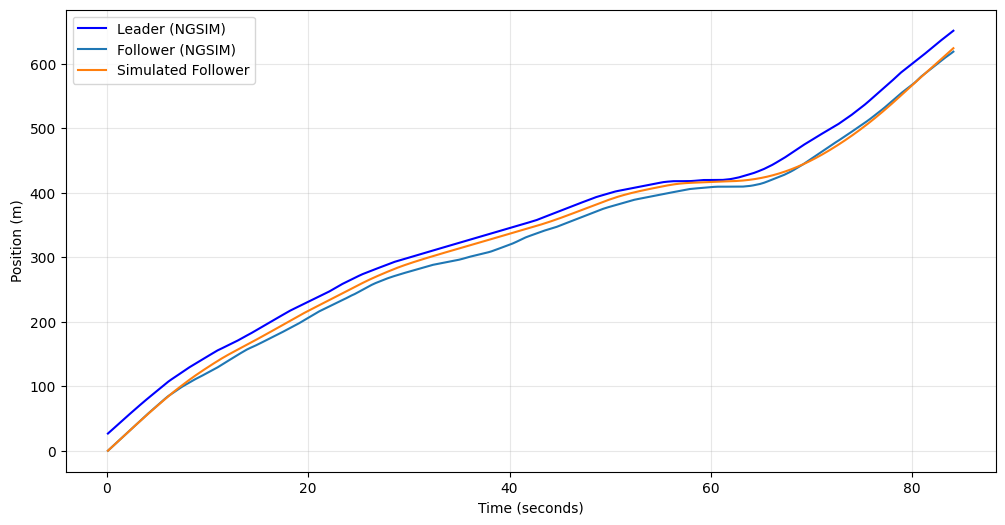

In [41]:
# Plot 1: Position vs Time — Comparing leader, real follower, and simulated follower
plt.figure(figsize = (12,6))
plt.plot(time_data, leader_position, label = 'Leader (NGSIM)', color = "blue")
plt.plot(time_data, data_subset['follower_position(m)'].values, label = 'Follower (NGSIM)')
plt.plot(time_data, sim_position, label = 'Simulated Follower')
plt.xlabel('Time (seconds)')
plt.ylabel('Position (m)')
plt.legend()
plt.grid(True, alpha = 0.3)
plt.show()

### Lab Activity#3

Look at the plots you just created and analyze the results. Write your observations below:

1. How well does the IDM simulation match the real NGSIM data for position?
   
2. Where do you see the biggest differences between simulation and reality? Why might these differences exist?
   

1. Similar trends, IDM shows more in depth different ranges of numbers.
2. Simulation offers more variety where as reality has more limited peramaters. 

# Extra Plots - Optional

In [ ]:
# Plot: Speed vs Time — Comparing real follower vs simulated follower


In [ ]:
# Plot: Acceleration vs Time — Comparing real follower vs simulated follower



In [ ]:
# Plot: Gap Distance vs Time — Comparing real gap vs simulated gap

# Calculate the real gap and simulated gap

# Plot the graph


# Experimenting with IDM Parameters -- Optional

One of the most powerful aspects of simulation is the ability to explore "what-if" scenarios. Let's see how changing the IDM parameters affects driving behavior.

Below, you will re-run the simulation with different parameter values and visualize the results.

In [ ]:
# Experiment 1: Change the desired time headway T
# Try three different values: T = 0.5s (aggressive), T = 1.5s (normal), T = 3.0s (cautious)
# Run the simulation for each and plot the position trajectories on the same graph

T_values = [0.5, 1.5, 3.0]
colors = ['red', 'blue', 'green']
labels = ['Aggressive (T=0.5s)', 'Normal (T=1.5s)', 'Cautious (T=3.0s)']

plt.figure(figsize=(12, 6))

# Plot the leader trajectory
plt.plot(time_data, leader_position, 'k--', linewidth=2, label='Leader')


    # Initialize arrays

    
    # Run simulation with this T value
    
    # Plot this trajectory
 

plt.xlabel('Time (seconds)')
plt.ylabel('Position (m)')
plt.title('Effect of Time Headway (T) on Following Behavior')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()